# Simple Emotion Prediction Analysis
Exploring the relationships between predicted emotions, probabilities, and actual emotions in our dataset.

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Basic plot settings
plt.rcParams['figure.figsize'] = [12, 6]

In [13]:
# Load and prepare the data
df = pd.read_csv('results.csv')

# Extract actual emotion from filename
df['actual_emotion'] = df['filename'].str.split('_').str[-1].str.replace('.wav', '')

print("Dataset Overview:")
print(f"Total samples: {len(df)}\n")
print("Actual emotions in dataset:")
print(df['actual_emotion'].value_counts())
print("\nPredicted emotions:")
print(df['emotion'].value_counts())

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'results.csv'

## Distribution of Predictions vs Actual Emotions

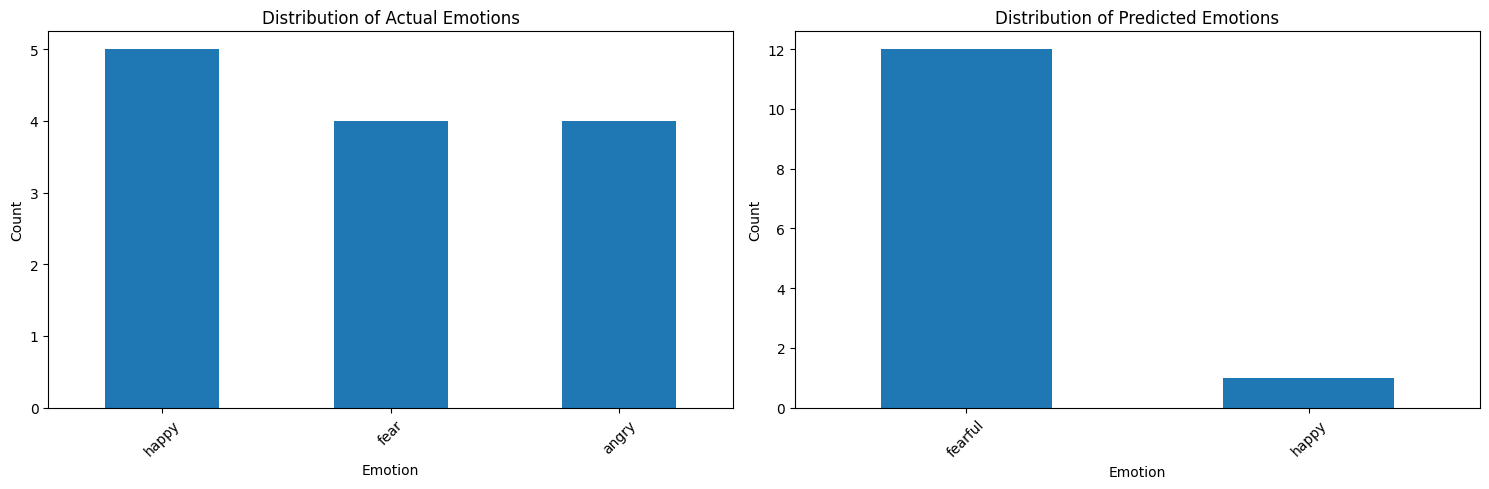

In [4]:
plt.figure(figsize=(15, 5))

# Plot actual emotions
plt.subplot(1, 2, 1)
df['actual_emotion'].value_counts().plot(kind='bar')
plt.title('Distribution of Actual Emotions')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Plot predicted emotions
plt.subplot(1, 2, 2)
df['emotion'].value_counts().plot(kind='bar')
plt.title('Distribution of Predicted Emotions')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Probability Distributions by Actual Emotion

<Figure size 1500x600 with 0 Axes>

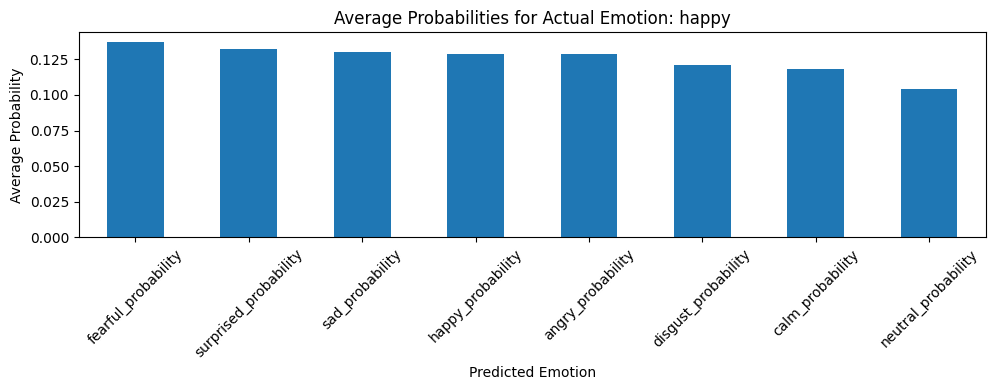

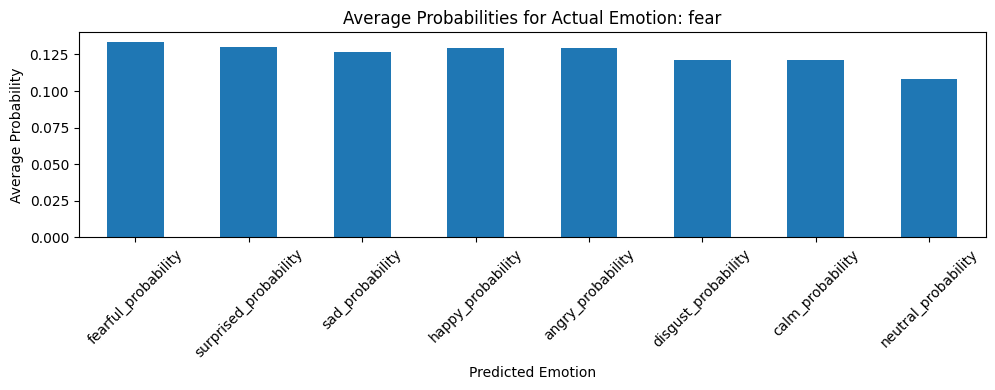

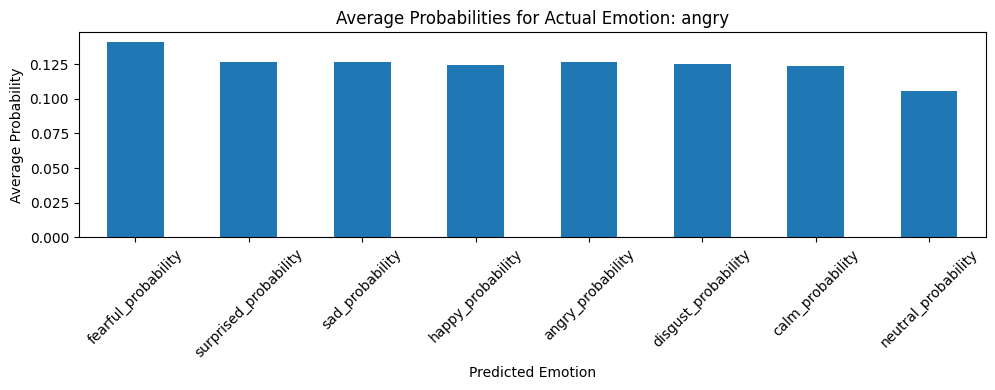

In [5]:
# Get probability columns
prob_cols = [col for col in df.columns if col.endswith('_probability')]

# Create boxplots of probabilities for each actual emotion
plt.figure(figsize=(15, 6))

# For each actual emotion, show the distribution of probabilities
for emotion in df['actual_emotion'].unique():
    emotion_data = df[df['actual_emotion'] == emotion]
    
    plt.figure(figsize=(10, 4))
    probs = emotion_data[prob_cols].mean()
    probs.plot(kind='bar')
    plt.title(f'Average Probabilities for Actual Emotion: {emotion}')
    plt.xlabel('Predicted Emotion')
    plt.ylabel('Average Probability')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Confidence Distribution

<Figure size 1200x500 with 0 Axes>

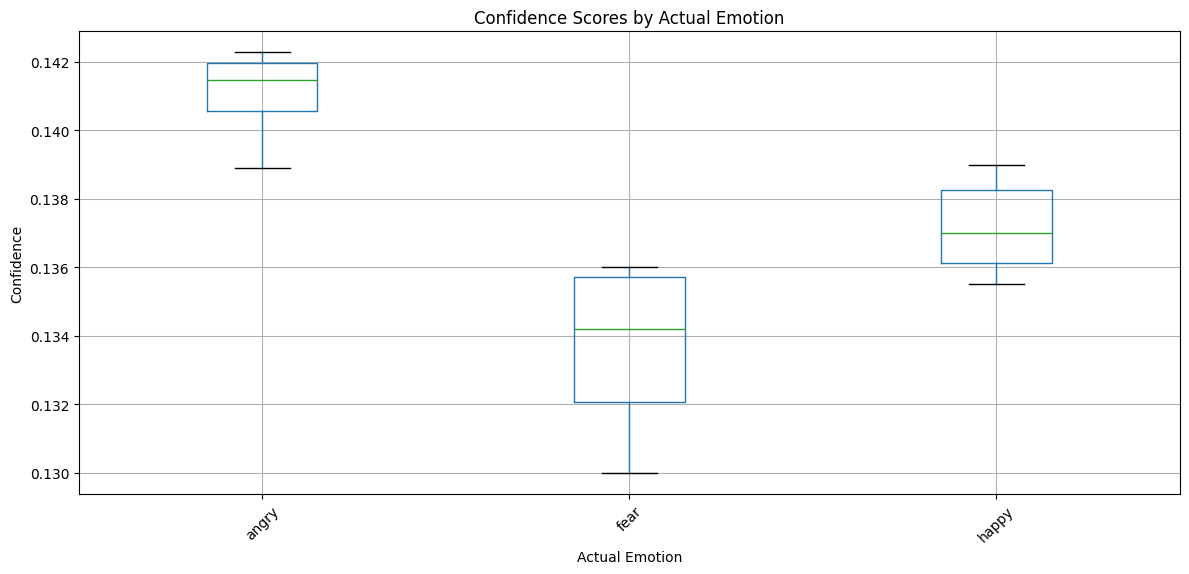


Average confidence by actual emotion:
actual_emotion
angry    0.141026
happy    0.137172
fear     0.133595
Name: confidence, dtype: float64


In [6]:
# Plot confidence distribution by actual emotion
plt.figure(figsize=(12, 5))
df.boxplot(column='confidence', by='actual_emotion')
plt.title('Confidence Scores by Actual Emotion')
plt.suptitle('')  # This removes the automatic suptitle
plt.xlabel('Actual Emotion')
plt.ylabel('Confidence')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print average confidence for each actual emotion
print("\nAverage confidence by actual emotion:")
print(df.groupby('actual_emotion')['confidence'].mean().sort_values(ascending=False))

## Predicted vs Actual Patterns

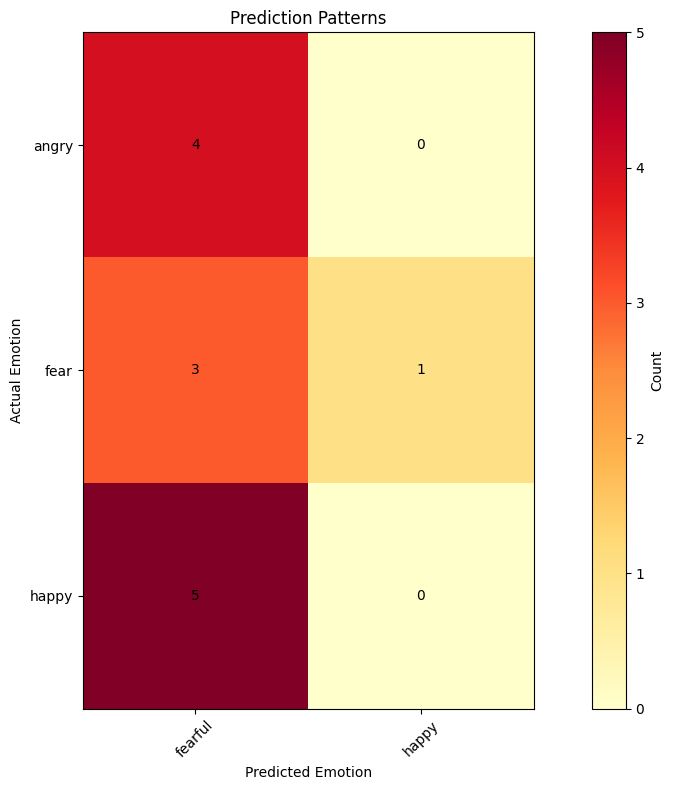


Most common prediction for each actual emotion:
happy: fearful (5/5 samples)
fear: fearful (3/4 samples)
angry: fearful (4/4 samples)


In [7]:
# Create a cross-tabulation of actual vs predicted emotions
prediction_patterns = pd.crosstab(df['actual_emotion'], df['emotion'])

# Plot as a heatmap
plt.figure(figsize=(12, 8))
plt.imshow(prediction_patterns, cmap='YlOrRd')
plt.colorbar(label='Count')

# Add labels
plt.xticks(range(len(prediction_patterns.columns)), prediction_patterns.columns, rotation=45)
plt.yticks(range(len(prediction_patterns.index)), prediction_patterns.index)
plt.xlabel('Predicted Emotion')
plt.ylabel('Actual Emotion')
plt.title('Prediction Patterns')

# Add count annotations
for i in range(len(prediction_patterns.index)):
    for j in range(len(prediction_patterns.columns)):
        plt.text(j, i, prediction_patterns.iloc[i, j],
                 ha='center', va='center')

plt.tight_layout()
plt.show()

# Print the most common prediction for each actual emotion
print("\nMost common prediction for each actual emotion:")
for emotion in df['actual_emotion'].unique():
    subset = df[df['actual_emotion'] == emotion]
    most_common = subset['emotion'].mode().iloc[0]
    count = len(subset[subset['emotion'] == most_common])
    total = len(subset)
    print(f"{emotion}: {most_common} ({count}/{total} samples)")